In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import cdmprof

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
# Load halo data from folder
halos = cdmprof.load_from_folder("/Users/rstiskalek/Projects/CDMprofile/data/test_halos")

In [17]:
# Check number of halos
print(f"Number of halos: {len(halos)}")
print(f"Total particles: {len(halos.radii):,}")

Number of halos: 225
Total particles: 237,117,637


In [18]:
# Get all halo IDs
print(f"First 10 halo IDs: {halos.halo_ids[:10]}")

First 10 halo IDs: [ 1  9 13 14 18 38 52 53 56 62]


In [19]:
# Load radii for a single halo by ID
halo_id = halos.halo_ids[10]
radii = halos[halo_id]
print(f"Halo {halo_id}: {len(radii):,} particles")
print(f"Radii range: [{radii.min():.2f}, {radii.max():.2f}]")

Halo 66: 3,898,666 particles
Radii range: [1.00, 927.37]


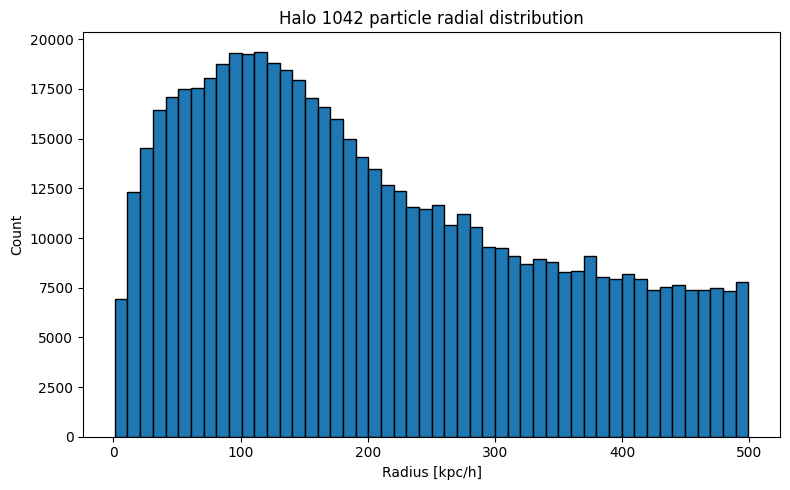

In [13]:
# Plot radial distribution
plt.figure(figsize=(8, 5))
plt.hist(radii, bins=50, edgecolor='black')
plt.xlabel("Radius [kpc/h]")
plt.ylabel("Count")
plt.title(f"Halo {halo_id} particle radial distribution")
plt.tight_layout()
plt.show()

In [9]:
# Iterate over halos
for i, (hid, r) in enumerate(halos):
    print(f"Halo {hid}: {len(r):,} particles")
    if i >= 4:
        print("...")
        break

Halo 1: 18,310,217 particles
Halo 9: 8,842,186 particles
Halo 13: 7,677,195 particles
Halo 14: 6,851,532 particles
Halo 18: 5,434,281 particles
...


In [ ]:
# Bin halos
# n_sample: downsample each halo to this many particles (None = no downsampling)
n_sample = None
binned = halos.bin(nbin=50, indices=[0, 1, 2], n_sample=n_sample, seed=42)
print(f"Binned shape: {binned['bin_counts'].shape}")
print(f"Halo IDs: {binned['halo_ids']}")
if n_sample is not None:
    print(f"Downsampled to {n_sample} particles per halo")

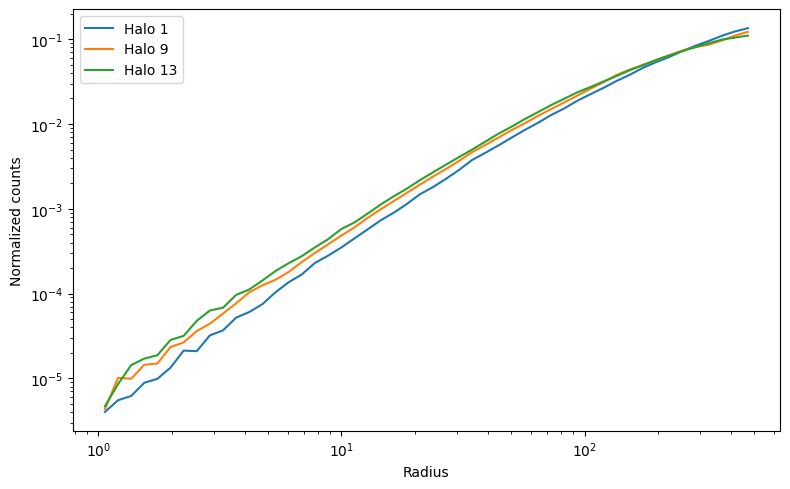

In [11]:
# Plot binned density profiles
plt.figure(figsize=(8, 5))
for i, hid in enumerate(binned['halo_ids']):
    density = binned['bin_counts'][i] / binned['npart'][i]
    plt.loglog(binned['bin_positions'], density, label=f"Halo {hid}")
plt.xlabel("Radius")
plt.ylabel("Normalized counts")
plt.legend()
plt.tight_layout()
plt.show()